In [1]:
!pip install -q transformers
!pip install -q opendatasets

import opendatasets as od
od.download("https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: rehman047
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection


100%|██████████| 3.30M/3.30M [00:00<00:00, 679MB/s]

In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

device="cuda" if torch.cuda.is_available() else "cpu"

In [3]:
device

'cuda'

In [4]:
df=pd.read_json("/content/news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json",lines=True)
#"/content/news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json"

In [5]:
df.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


In [6]:
df.shape

(26709, 3)

In [7]:
df.isnull().sum()

,0
article_link,0
headline,0
is_sarcastic,0


In [8]:
df=df.dropna()
df=df.drop_duplicates()

In [9]:
df.shape

(26708, 3)

In [10]:
df.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


In [11]:
df.drop("article_link",axis=1,inplace=True)

In [12]:
df.head()

,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0


In [13]:
df['is_sarcastic'].value_counts()

,count
is_sarcastic,
0,14984
1,11724


In [14]:
df.is_sarcastic=df["is_sarcastic"].map({0:"not-sarcastic",1:"sarcastic"})

In [15]:
df['is_sarcastic'].value_counts()

,count
is_sarcastic,
not-sarcastic,14984
sarcastic,11724


<Axes: ylabel='count'>

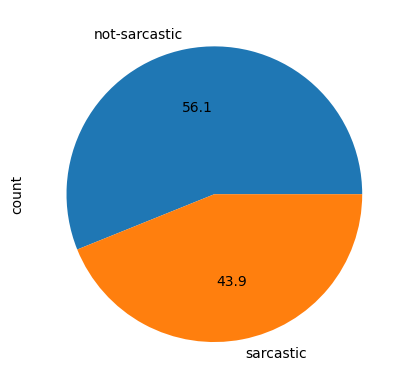

In [16]:
df['is_sarcastic'].value_counts().plot(kind="pie",autopct="%.1f")

In [17]:
df.head()

,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,not-sarcastic
1,the 'roseanne' revival catches up to our thorn...,not-sarcastic
2,mom starting to fear son's web series closest ...,sarcastic
3,"boehner just wants wife to listen, not come up...",sarcastic
4,j.k. rowling wishes snape happy birthday in th...,not-sarcastic


In [18]:
df.is_sarcastic=df["is_sarcastic"].map({"not-sarcastic":0,"sarcastic":1})

In [19]:
df.head()

,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0


In [20]:
X_train,X_test,Y_train,Y_test=train_test_split(df['headline'].values,df['is_sarcastic'].values,test_size=0.3)
X_val,X_test,Y_val,Y_test=train_test_split(X_test,Y_test,test_size=0.5)

In [21]:
X_train.shape

(18695,)

In [22]:
X_train

array(['why some vaccines require more than one dose',
       "8 'walking dead' secrets you didn't know, according to a dead man",
       "area man accidentally responds to own 'm4m' ad", ...,
       'trump welcomes jefferson davis statue as special state of the union guest',
       'everything sees',
       "cecily strong responds to 'weekend update' change"], dtype=object)

In [23]:
Y_train

array([0, 0, 1, ..., 1, 0, 0])

In [25]:
print(f"Size of training data {X_train.shape[0]}, %total size is {X_train.shape[0]/df.shape[0]}")
print(f"Size of validation data {X_val.shape[0]}, %total size is {X_val.shape[0]/df.shape[0]}")
print(f"Size of test data {X_test.shape[0]}, %total size is {X_test.shape[0]/df.shape[0]}")

Size of training data 18695, %total size is 0.6999775348210274
Size of validation data 4006, %total size is 0.14999251160700913
Size of test data 4007, %total size is 0.15002995357196347


In [26]:
tokenizer=AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
bert_model=AutoModel.from_pretrained("google-bert/bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [31]:
bert_model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [38]:
class MyDataset(Dataset):
  def __init__(self,X,Y):
    super().__init__()
    self.input=[
       tokenizer(x, max_length=1000,truncate=True,padding=True,return_tensors='pt') for x in X
    ]
    self.output=torch.tensor(Y,dtype=torch.float32).to(device)
  def __len__(self):
    return len(self.input)
  def __getitem__(self,index):
    return self.input[index],self.output[index]

In [39]:
train_dataset=MyDataset(X_train,Y_train)
val_dataset=MyDataset(X_val,Y_val)
test_dataset=MyDataset(X_test,Y_test)

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2402: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


In [40]:
len(train_dataset)

18695

In [41]:
train_dataset[5]

({'input_ids': tensor([[ 101, 2975, 2637, 2044, 1996, 3864, 1029, 2182, 1005, 1055, 1037, 2307,
          5724, 1012,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])},
 tensor(0., device='cuda:0'))

In [42]:
X_train[5]

"leaving america after the elections? here's a great option."

In [44]:
tokenizer.convert_ids_to_tokens(2637) # this is token for word america, which is one of the indices in 5th index of X_train

'america'

In [50]:
class My_Bert(nn.Module):
  def __init__(self,bert):
    super().__init__()
    self.bert = bert
    self.L1 = nn.Linear(768,499)
    self.L2 = nn.Linear(499,1)
    self.sigmoid=nn.Sigmoid()
    self.dropper=nn.Dropout(0.26)
  def forward(self,x,mask):
    x=self.bert(x,mask,return_dict=False)[0][:,0]
    x=self.L1(x)
    x=self.L2(self.dropper(x))
    x=self.sigmoid(x)
    return x



In [46]:
help(nn.Dropout)

Help on class Dropout in module torch.nn.modules.dropout:

class Dropout(_DropoutNd)
 |  Dropout(p: float = 0.5, inplace: bool = False) -> None
 |
 |  During training, randomly zeroes some of the elements of the input tensor with probability :attr:`p`.
 |
 |  The zeroed elements are chosen independently for each forward call and are sampled from a Bernoulli distribution.
 |
 |  Each channel will be zeroed out independently on every forward call.
 |
 |  This has proven to be an effective technique for regularization and
 |  preventing the co-adaptation of neurons as described in the paper
 |  `Improving neural networks by preventing co-adaptation of feature
 |  detectors`_ .
 |
 |  Furthermore, the outputs are scaled by a factor of :math:`\frac{1}{1-p}` during
 |  training. This means that during evaluation the module simply computes an
 |  identity function.
 |
 |  Args:
 |      p: probability of an element to be zeroed. Default: 0.5
 |      inplace: If set to ``True``, will do this op

In [51]:
my_bert=My_Bert(bert_model)

In [52]:
my_bert

My_Bert(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=Tr